<a href="https://colab.research.google.com/github/jittavijay/cpp/blob/main/Statisical_Analysis_of_Apple_events.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu
import os # Imported inside main, but good to have here for consistency if needed globally

# Define global constants for file paths and event study parameters
DATA_PATH = "/content/APPL.csv"  # Path to the Apple stock data CSV
OUTPUT_DIR = "outputs"           # Directory to save output plots and summary

# List of significant events to analyze, including their date, name, and category
EVENTS = [
    {"date": "1984-01-24", "event": "Macintosh Launch", "category": "Product"},
    {"date": "1985-09-16", "event": "Steve Jobs Ousted", "category": "Leadership"},
    {"date": "1997-09-16", "event": "Steve Jobs Returns", "category": "Leadership"},
    {"date": "2001-01-09", "event": "iTunes Launch", "category": "Product"},
    {"date": "2001-10-23", "event": "iPod Launch", "category": "Product"},
    {"date": "2007-01-09", "event": "iPhone Launch", "category": "Product"},
    {"date": "2011-08-24", "event": "Tim Cook becomes CEO", "category": "Leadership"},
    {"date": "2014-09-09", "event": "iPhone 6 & Apple Watch", "category": "Product"},
    {"date": "2018-08-02", "event": "Apple reaches $1T Market Cap", "category": "Milestone"},
    {"date": "2020-03-23", "event": "COVID Recovery Phase", "category": "Macro"},
]

# Define window sizes for the event study (in trading days)
PRE_WINDOW = 5     #30     # Days before the event to include in the window
POST_WINDOW = 5     #30    # Days after the event to include in the window
ESTIMATION_WINDOW = 20 #120   # Days used to estimate normal returns before the event


def load_data(path):
    """Loads stock data, performs initial cleaning, and calculates financial metrics."""
    df = pd.read_csv(path)  # Read the CSV file into a DataFrame
    df["Date"] = pd.to_datetime(df["Date"])  # Convert 'Date' column to datetime objects
    df = df.sort_values("Date").reset_index(drop=True)  # Sort by date and reset index
    df = df[df["Date"] <= "2022-12-31"].copy()  # Filter data up to end of 2022

    # Calculate various financial metrics
    df["Daily_Return"] = df["Adj Close"].pct_change()  # Percentage change in adjusted close price
    df["Log_Return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1)) # Logarithmic return
    df["MA10"] = df["Adj Close"].rolling(10).mean()  # 10-day Simple Moving Average
    df["MA30"] = df["Adj Close"].rolling(30).mean()  # 30-day Simple Moving Average
    df["Volatility10"] = df["Daily_Return"].rolling(10).std() # 10-day rolling standard deviation of daily returns

    # df.head() # This line displays the head but doesn't store it, removed if not used for explicit output
    return df


def nearest_trading_index(df, event_date):
    """Finds the index of the nearest trading day in the DataFrame to a given event date."""
    event_date = pd.to_datetime(event_date)  # Ensure event_date is a datetime object
    # Calculate absolute time difference and find the index of the minimum difference
    return (df["Date"] - event_date).abs().idxmin()


def analyze_event(df, event_row):
    """Performs event study analysis for a single event, calculates abnormal returns, CAR, and statistical tests."""
    # Find the index of the event's nearest trading day
    idx = nearest_trading_index(df, event_row["date"])

    # Define the event window boundaries (pre-window, event day, post-window)
    start = max(0, idx - PRE_WINDOW)
    end = min(len(df) - 1, idx + POST_WINDOW)
    window = df.loc[start:end].copy()  # Extract the data for the event window
    # Calculate Event_Day relative to the actual event (0 is event day)
    window["Event_Day"] = np.arange(start - idx, end - idx + 1)

    # Estimate expected return from a period before the event window
    # Drop any NaN values that might arise from `pct_change()` at the beginning
    estimation = df.loc[max(0, idx - ESTIMATION_WINDOW): idx - 1, "Daily_Return"].dropna()
    expected_return = estimation.mean() if len(estimation) else 0.0 # Calculate mean, handle empty estimation

    # Calculate Abnormal Returns (actual daily return - expected return)
    window["Abnormal_Return"] = window["Daily_Return"] - expected_return
    # Calculate Cumulative Abnormal Return (CAR)
    window["CAR"] = window["Abnormal_Return"].fillna(0).cumsum() # Fill NaN with 0 for cumsum if needed

    # Separate daily returns into pre-event and post-event periods for statistical tests
    pre = window[window["Event_Day"] < 0]["Daily_Return"].dropna()
    post = window[window["Event_Day"] > 0]["Daily_Return"].dropna()

    # Perform t-test (parametric) and Mann-Whitney U test (non-parametric)
    t_stat, t_p = ttest_ind(pre, post, equal_var=False, nan_policy="omit")
    _, u_p = mannwhitneyu(pre, post, alternative="two-sided")

    # Compile all relevant results for the event
    result = {
        "Event": event_row["event"],
        "Category": event_row["category"],
        "Nearest Trading Date": df.loc[idx, "Date"].date().isoformat(),
        "Pre Mean Return": pre.mean(),
        "Post Mean Return": post.mean(),
        "Pre Volatility": pre.std(),
        "Post Volatility": post.std(),
        "Event Day Return": window.loc[window["Event_Day"] == 0, "Daily_Return"].iloc[0],
        "CAR (+30d)": window["CAR"].iloc[-1], # CAR at the end of the post-window
        "T-test p": t_p,
        "Mann-Whitney p": u_p,
    }
    return result, window


def main():
    """Main function to run the event study analysis for all defined events."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)  # Create output directory if it doesn't exist

    df = load_data(DATA_PATH)  # Load and preprocess the stock data
    all_results = []  # List to store results for all events

    # Iterate through each event and perform analysis
    for event in EVENTS:
        result, window = analyze_event(df, event)  # Analyze the current event
        window.describe()
        all_results.append(result)  # Add results to the list

        # Plotting Adjusted Close Price around the event
        plt.figure(figsize=(8, 4)) # Set figure size
        plt.plot(window["Event_Day"], window["Adj Close"]) # Plot adjusted close price
        plt.axvline(0, linestyle="--", color="black") # Mark event day with a vertical line
        plt.title(event["event"]) # Set plot title
        plt.xlabel("Days Relative to Event") # Set x-axis label
        plt.ylabel("Adj Close ($)") # Set y-axis label
        plt.tight_layout() # Adjust layout to prevent labels overlapping
        # Save the plot to the output directory
        plt.savefig(os.path.join(OUTPUT_DIR, f"{event['event'].replace(' ', '_')}.png"), dpi=160)
        plt.close() # Close the plot to free memory

        # Plotting Cumulative Abnormal Return (CAR) around the event
        plt.figure(figsize=(8, 4))
        plt.plot(window["Event_Day"], window["CAR"], color="red") # Plot CAR in red
        plt.axvline(0, linestyle="--", color="black") # Mark event day
        plt.axhline(0, linestyle=":", color="grey") # Add a horizontal line at 0 for CAR reference
        plt.title(f"{event['event']} - Cumulative Abnormal Return (CAR)") # Set plot title
        plt.xlabel("Days Relative to Event")
        plt.ylabel("CAR")
        plt.tight_layout()
        # Save the CAR plot to the output directory
        plt.savefig(os.path.join(OUTPUT_DIR, f"{event['event'].replace(' ', '_')}_CAR.png"), dpi=160)
        plt.close()

    # Convert all results into a pandas DataFrame for summarization
    summary = pd.DataFrame(all_results)
    # Add a 'Significance' column based on T-test p-value (p < 0.05)
    summary["Significance"] = np.where(summary["T-test p"] < 0.05, "Significant", "Not significant")
    # Save the summary DataFrame to a CSV file
    summary.to_csv(os.path.join(OUTPUT_DIR, "event_summary.csv"), index=False)
    print(summary) # Print the summary to console


if __name__ == "__main__":
    main() # Execute the main function when the script is run


                          Event    Category Nearest Trading Date  \
0              Macintosh Launch     Product           1984-01-24   
1             Steve Jobs Ousted  Leadership           1985-09-16   
2            Steve Jobs Returns  Leadership           1997-09-16   
3                 iTunes Launch     Product           2001-01-09   
4                   iPod Launch     Product           2001-10-23   
5                 iPhone Launch     Product           2007-01-09   
6          Tim Cook becomes CEO  Leadership           2011-08-24   
7        iPhone 6 & Apple Watch     Product           2014-09-09   
8  Apple reaches $1T Market Cap   Milestone           2018-08-02   
9          COVID Recovery Phase       Macro           2020-03-23   

   Pre Mean Return  Post Mean Return  Pre Volatility  Post Volatility  \
0         0.007153         -0.018592        0.014196         0.033949   
1         0.010015          0.020901        0.022787         0.033614   
2         0.000425         -0.00

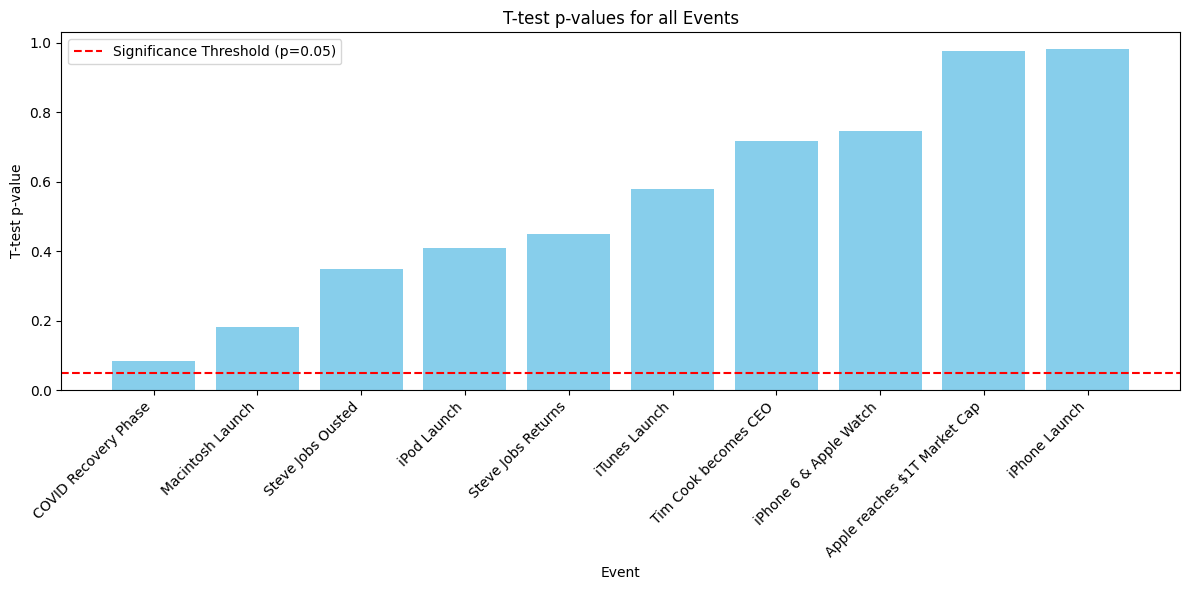

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = "outputs"

# Load the summary results from the CSV file generated by the event study
summary = pd.read_csv(os.path.join(OUTPUT_DIR, "event_summary.csv"))

# Sort the DataFrame by T-test p-value in ascending order for better visualization
summary = summary.sort_values(by="T-test p", ascending=True)

# Create a bar chart to visualize T-test p-values for all events
plt.figure(figsize=(12, 6)) # Set figure size for better readability
plt.bar(summary["Event"], summary["T-test p"], color='skyblue') # Plot events vs. p-values
# Add a horizontal line at y=0.05 to indicate the common significance threshold
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Threshold (p=0.05)')
plt.xlabel("Event") # Set x-axis label
plt.ylabel("T-test p-value") # Set y-axis label
plt.title("T-test p-values for all Events") # Set chart title
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better visibility
plt.legend() # Display the legend for the significance threshold line
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot


# Documentation of Functions and Algorithm

This notebook performs an event study analysis on Apple (APPL) stock data to assess the impact of significant historical events on its stock returns. Below is a detailed documentation of the functions and the underlying algorithm.

## Global Constants

-   `DATA_PATH`: Path to the input CSV file containing stock data (e.g., `/content/APPL.csv`).
-   `OUTPUT_DIR`: Directory where output plots and summary CSV will be saved (`outputs`).
-   `EVENTS`: A list of dictionaries, each representing an event. Each dictionary contains:
    -   `date`: The date of the event (string in 'YYYY-MM-DD' format).
    -   `event`: A descriptive name of the event (string).
    -   `category`: The category of the event (e.g., 'Product', 'Leadership', 'Milestone', 'Macro').
-   `PRE_WINDOW`: Number of trading days before the event date to include in the analysis window (30 days).
-   `POST_WINDOW`: Number of trading days after the event date to include in the analysis window (30 days).
-   `ESTIMATION_WINDOW`: Number of trading days used to estimate the expected daily return before the event (120 days).

## Functions

### `load_data(path)`

-   **Description**: Loads historical stock data from a CSV file, performs initial data cleaning, and calculates several financial metrics.
-   **Parameters**:
    -   `path` (str): The file path to the CSV containing the stock data.
-   **Operations**:
    1.  Reads the CSV file into a pandas DataFrame.
    2.  Converts the 'Date' column to datetime objects.
    3.  Sorts the DataFrame by 'Date' and resets the index.
    4.  Filters data to include only dates up to '2022-12-31'.
    5.  Calculates:
        -   `Daily_Return`: Percentage change in 'Adj Close' price.
        -   `Log_Return`: Logarithmic daily return.
        -   `MA10`: 10-day Simple Moving Average of 'Adj Close'.
        -   `MA30`: 30-day Simple Moving Average of 'Adj Close'.
        -   `Volatility10`: 10-day rolling standard deviation of 'Daily_Return'.
-   **Returns**:
    -   `df` (pd.DataFrame): The processed DataFrame with added financial metrics.

### `nearest_trading_index(df, event_date)`

-   **Description**: Finds the index of the trading day in the DataFrame that is closest to a given calendar event date.
-   **Parameters**:
    -   `df` (pd.DataFrame): The stock data DataFrame.
    -   `event_date` (str or datetime): The date of the event.
-   **Returns**:
    -   `int`: The integer index of the nearest trading day in the DataFrame.

### `analyze_event(df, event_row)`

-   **Description**: Performs the event study analysis for a single event, calculating abnormal returns, cumulative abnormal returns, and conducting statistical tests.
-   **Parameters**:
    -   `df` (pd.DataFrame): The complete stock data DataFrame.
    -   `event_row` (dict): A dictionary containing event details (e.g., `{"date": "...", "event": "...", "category": "..."}`).
-   **Algorithm**:
    1.  **Identify Event Window**: Determines the `PRE_WINDOW` days before and `POST_WINDOW` days after the event's nearest trading date.
    2.  **Estimate Expected Return**: Calculates the mean `Daily_Return` over an `ESTIMATION_WINDOW` period prior to the event (excluding the event window itself).
    3.  **Calculate Abnormal Returns**: Subtracts the `expected_return` from each `Daily_Return` within the event window to get `Abnormal_Return`.
    4.  **Calculate Cumulative Abnormal Return (CAR)**: Computes the cumulative sum of `Abnormal_Return` within the event window.
    5.  **Statistical Testing**: Splits the daily returns within the event window into 'pre-event' (days < 0) and 'post-event' (days > 0) periods.
        -   Performs an independent two-sample t-test (`ttest_ind`) to compare the means of pre-event and post-event daily returns.
        -   Performs a Mann-Whitney U rank test (`mannwhitneyu`) as a non-parametric alternative.
-   **Returns**:
    -   `result` (dict): A dictionary containing various metrics for the event:
        -   'Event', 'Category', 'Nearest Trading Date'
        -   'Pre Mean Return', 'Post Mean Return', 'Pre Volatility', 'Post Volatility'
        -   'Event Day Return', 'CAR (+30d)' (CAR at the end of the post-window)
        -   'T-test p', 'Mann-Whitney p'
    -   `window` (pd.DataFrame): A DataFrame containing the data for the specific event window, including 'Event_Day', 'Abnormal_Return', and 'CAR'.

### `main()`

-   **Description**: Orchestrates the entire event study analysis, iterating through all defined events, generating plots, and summarizing results.
-   **Operations**:
    1.  Creates the `OUTPUT_DIR` if it doesn't exist.
    2.  Loads the main stock data using `load_data()`.
    3.  Iterates through each event in the `EVENTS` list:
        -   Calls `analyze_event()` for each event to get its results and window data.
        -   Appends the `result` dictionary to a list `all_results`.
        -   Generates and saves two plots for each event in the `OUTPUT_DIR`:
            -   **Adjusted Close Price Plot**: Shows 'Adj Close' prices around the event, with a vertical line marking the event day.
            -   **Cumulative Abnormal Return (CAR) Plot**: Shows the `CAR` around the event, with a vertical line marking the event day and a horizontal line at zero CAR.
    4.  Converts `all_results` into a `summary` pandas DataFrame.
    5.  Adds a 'Significance' column to the `summary` DataFrame, marking events as 'Significant' if their T-test p-value is less than 0.05.
    6.  Saves the `summary` DataFrame to `event_summary.csv` in the `OUTPUT_DIR`.
    7.  Prints the `summary` DataFrame to the console.

## Overall Algorithm (Event Study)

1.  **Data Loading and Preprocessing**: Load historical stock data, clean it, and calculate essential metrics like daily returns and moving averages.
2.  **Event Identification**: Define a list of specific events to study, each with a date, name, and category.
3.  **Event Window Definition**: For each event, define a specific time window surrounding the event date (e.g., 30 days before and 30 days after).
4.  **Expected Return Estimation**: Calculate the average daily return from a period prior to the event window (e.g., 120 days) to serve as the 'normal' or 'expected' return.
5.  **Abnormal Return Calculation**: For each day within the event window, calculate the abnormal return by subtracting the estimated expected return from the actual daily return.
6.  **Cumulative Abnormal Return (CAR)**: Sum the abnormal returns over the event window to understand the total abnormal performance around the event.
7.  **Statistical Inference**: Use statistical tests (like t-test and Mann-Whitney U test) to determine if there's a statistically significant difference in returns between the pre-event and post-event periods, indicating a significant market reaction to the event.
8.  **Visualization**: Generate plots to visually inspect the stock's price behavior and CAR around each event.
9.  **Summarization**: Compile all event results into a summary table, including metrics and statistical significance, for easy interpretation.